# `velocity_ot` — train an OT velocity field and plot trajectories

Runs the full pipeline end-to-end:

1. **Load data** into an `AnnData` (your own, or a synthetic rotating ring).
2. **Fit** an autonomous velocity field `v_φ : ℝ^D → ℝ^D` with `VelocityFieldEstimator`.
3. **Inspect** the fitted field (streamplot) and training curves.
4. **Integrate & plot trajectories** rolled forward from seed points.
5. Read the **outputs** written back into `adata.obsm["velocity_field"]`.

**Data contract:** spatial coordinates in `adata.X` `[N, D]`; circular
coordinate (radians) in `adata.obs['circular_coords']` `[N]`.

**The four loss terms** (all optimal-transport terms via `POT`):
`L = λ₁·KE + λ₂·stationarity + λ₃·align + λ₄·OT_sub`, where *stationarity*
flows a localized arc around the cycle and matches its time-marginal to the full
data, and *OT_sub* enforces that a subset returns to itself after one cycle.

> Place this notebook next to the `velocity_ot/` package folder (or adjust the
> path in the first cell).

In [2]:
# --- imports & setup ---
import sys, pathlib
PKG_PARENT = None  # set to the folder that CONTAINS velocity_ot/ if needed
if PKG_PARENT:
    sys.path.insert(0, PKG_PARENT)
else:
    for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (p / "velocity_ot" / "__init__.py").exists():
            sys.path.insert(0, str(p)); break

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
%matplotlib inline

import velocity_ot as vo
print("velocity_ot", vo.__version__)

velocity_ot 0.1.0


## 1. Load your data

The estimator reads:

- **coordinates** `x` from `adata.X` — shape `[N, D]`;
- **circular coordinate** `θ` (radians in `[0, 2π)`) from
  `adata.obs['circular_coords']` — shape `[N]`.

**Don't have `θ`?** Compute a *persistent-cohomology circular coordinate*
(e.g. `dreimac.CircularCoords`) from your point cloud and store it (in radians)
as `adata.obs['circular_coords']`. `θ` is the phase of the cycle each point sits at.

Set `USE_YOUR_OWN_DATA = True` and fill in the block below. Otherwise a
synthetic rotating ring is used so the notebook runs out of the box.

In [3]:
# ======================= PLUG IN YOUR DATA HERE =======================
USE_YOUR_OWN_DATA = True

if USE_YOUR_OWN_DATA:
    # --- Option A: from an .h5ad (spatial in .X, circular coord in obs) ---
    adata = ad.read_h5ad("adata_lcycle_wangle.h5ad")
    # assert "circular_coords" in adata.obs

    # --- Option B: from numpy arrays you have in memory ---
    # coords = ...                      # [N, D] float  (spatial coordinates)
    # theta  = ...                      # [N] radians in [0, 2*pi)
    # adata = ad.AnnData(X=coords.astype("float32"))
    # adata.obs["circular_coords"] = np.asarray(theta, dtype="float32")
    #raise NotImplementedError("Fill in your data, then set USE_YOUR_OWN_DATA = True.")
else:
    # --- Synthetic fallback: a rotating ring with non-uniform angular density ---
    rng = np.random.default_rng(0)
    N = 400
    theta  = np.sort(rng.beta(2.0, 5.0, size=N) * 2.0 * np.pi)   # clumped phases
    radius = 1.0 + 0.03 * rng.standard_normal(N)
    coords = np.stack([radius * np.cos(theta), radius * np.sin(theta)], axis=1).astype("float32")

    adata = ad.AnnData(X=coords)                            # spatial -> adata.X
    adata.obs["circular_coords"] = theta.astype("float32")  # circular coord -> obs

print("adata:", adata)
print("X", adata.X.shape, "| circular_coords", adata.obs["circular_coords"].shape)

adata: AnnData object with n_obs × n_vars = 2000 × 2
    obs: 'circular_coords'
    obsm: 'Field'
X (2000, 2) | circular_coords (2000,)


### Quick look at the data (coloured by θ)

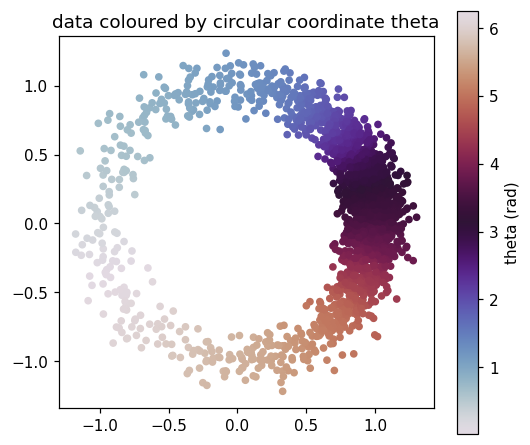

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=110)
c = np.asarray(adata.obs["circular_coords"])
sc = ax.scatter(adata.X[:, 0], adata.X[:, 1], c=c, cmap="twilight", s=16)
ax.set_aspect("equal"); ax.set_title("data coloured by circular coordinate theta")
fig.colorbar(sc, ax=ax, label="theta (rad)"); plt.show()

## 2. Fit the velocity field

Key knobs:

- `intrinsic_dim` — manifold dimension for estimating `∇θ` (`1` for a circle).
- `lambda_*` — weights of the four loss terms.
- `stationarity_seed_frac` — size of the localized arc that seeds the
  stationarity term (small ⇒ the clump must flow further to reproduce the data).
- `n_steps` / `method` — ODE integration for one cycle.

By default coordinates come from `adata.X` and `θ` from
`adata.obs['circular_coords']`, so `fit` needs no key arguments. Training prints
the four loss terms per logged epoch.

#### Checking circular grad works

In [ ]:
est = vo.VelocityFieldEstimator(
    hidden_dims=(64, 64),
    activation="silu",
    n_steps=10,               # ODE steps per cycle during training
    method="rk4",
    T=1.0,
    lambda_align=0.0,
    lambda_ke=0.0,
    lambda_ot_sub=0.0,
    lambda_stationarity=0.0,
    init=False, 
    lambda_init=0.0,
    init_epochs= 50                
)

est.fit(adata, stages=[
    dict(name="Initialization",    epochs=50, lr=1e-2, lambda_ke = 1e-4, lambda_align=1.0),
    dict(name="Align", epochs=50, lr=1e-3, lambda_ke=1e-5, lambda_stationarity=0.05, lambda_align=1.0),
    dict(name="Stationarity", epochs = 50,lr=1e-4, lambda_ke=1e-3,lambda_stationarity=1.0, lambda_ot_sub=0.1)
    ])  # reads adata.X and adata.obs['circular_coords']

[Initialization]: 100%|██████████| 50/50 [00:08<00:00,  5.74it/s, tot=0.002, ke=1.417, align=0.002] 


[Initialization] best epoch 49 (total=0.0017) restored


[Stationarity]: 100%|██████████| 50/50 [02:48<00:00,  3.36s/it, tot=0.020, ke=4.695, stat=0.114, align=0.004]


[Stationarity] best epoch 40 (total=0.0185) restored


[Finetuning]: 100%|██████████| 50/50 [04:58<00:00,  5.97s/it, tot=0.081, ke=5.987, stat=0.065, sub=0.101]

[Finetuning] best epoch 46 (total=0.0776) restored


### Training curves

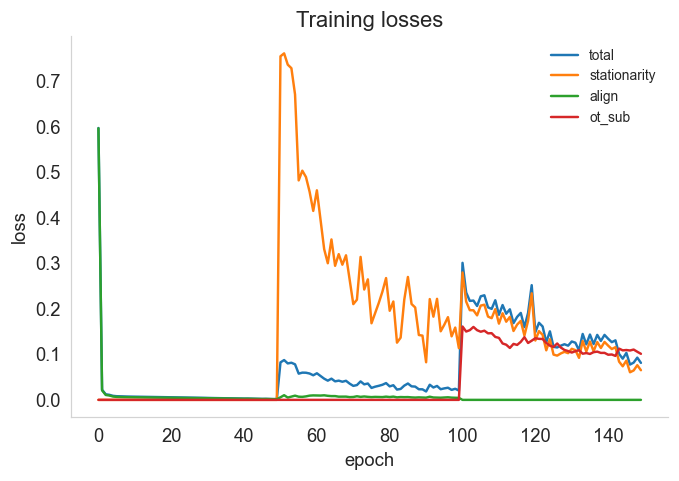

In [58]:
ax = vo.plot_loss_history(est)
plt.show()

## 3. Inspect the fitted velocity field

For 2-D data the streamplot shows the whole field, coloured by speed. It should
circulate around the ring, following the circular-coordinate gradient.

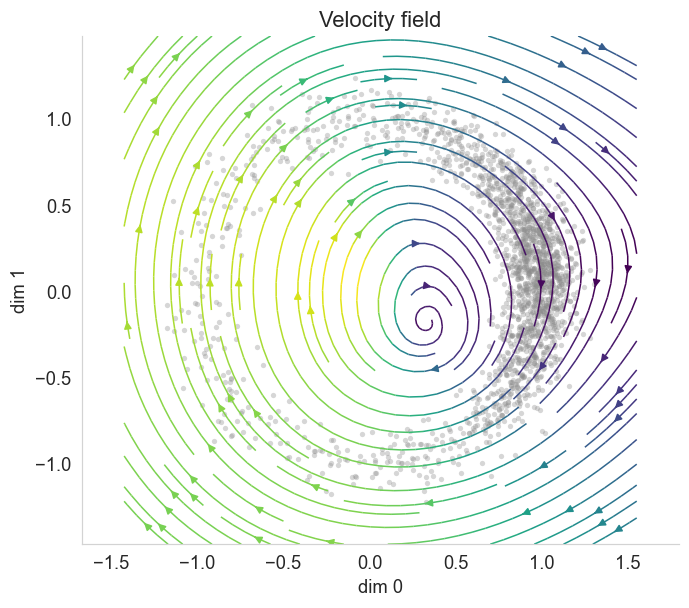

mean speed |v|          : 2.373


In [59]:
ax = vo.plot_velocity_field(est, adata.X, dims=(0, 1), streamplot=True, quiver=False)
plt.show()

# how rotational is it? (cosine with the analytic +theta tangent, for the ring)
v = adata.obsm["velocity_field"]
th = np.asarray(adata.obs["circular_coords"])
tangent = np.stack([-np.sin(th), np.cos(th)], axis=1)
#cos = (v * tangent).sum(1) / (np.linalg.norm(v, axis=1) * np.linalg.norm(tangent, axis=1) + 1e-9)
print(f"mean speed |v|          : {np.linalg.norm(v, axis=1).mean():.3f}")
#print(f"mean cos(v, +theta dir) : {cos.mean():.3f}   (1.0 = perfectly rotational)")

## 4. Integrate & plot trajectories

Roll seed points forward through the autonomous field for one cycle. Lines are
coloured by time (start = open circle, end = star). The stationarity term drives
the flow to sweep the whole ring; with enough training the trajectories close
after one cycle.

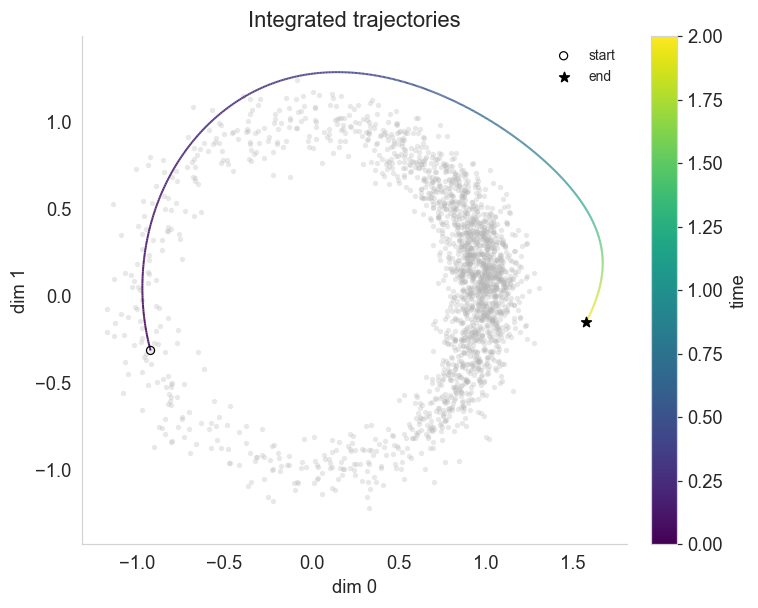

In [70]:
ax = vo.plot_trajectories(est, X =adata.X,n_seeds=1, n_steps=1000,T=2.0)
plt.show()

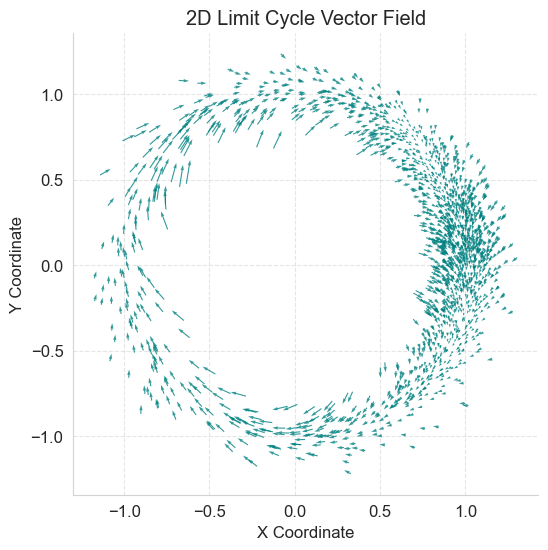

In [64]:
import numpy as np
import matplotlib.pyplot as plt

X = np.asarray(adata.X, dtype=float)

G = adata.obsm['velocity_init']

plt.figure(figsize=(6, 6))
plt.quiver(X[:, 0], X[:, 1], G[:, 0], G[:, 1],angles='xy', scale_units='xy', scale=1.0, color='teal', alpha=0.8)

plt.title("2D Limit Cycle Vector Field")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')

plt.show()

In [ ]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2053179 stored elements and shape (3058, 2000)>

In [ ]:
# Raw trajectory array for your own analysis: [n_steps+1, n_seeds, D]
seeds = adata.X[::40]
traj, times = vo.integrate_trajectories(est, seeds, T=1.0, n_steps=100)
print("trajectory array:", traj.shape, "  (n_steps+1, n_seeds, D)")
print("times:", times.shape, "from", round(float(times[0]), 2), "to", round(float(times[-1]), 2))

# Field + a few smoothed trajectories together.
fig, ax = plt.subplots(figsize=(7, 6), dpi=110)
vo.plot_velocity_field(est, adata.X, streamplot=True, quiver=False, ax=ax,
                       title="field + trajectories")
vo.plot_trajectories(est, seeds=seeds, X=adata.X, T=1.0, n_steps=100, smooth=True,
                     show_background=False, ax=ax, title=None)
plt.show()

## 5. Outputs written back to `AnnData`

`fit` stores results on the object:

- `adata.obsm["velocity_field"]` — fitted velocities at every point.
- `adata.obsm["grad_theta"]` — the estimated grad(theta) target field.
- `adata.uns["velocity_ot"]` — loss history and run configuration.

The field also evaluates at **out-of-sample** points via `est.predict`.

In [ ]:
print("obsm keys :", list(adata.obsm.keys()))
print("velocity_field:", adata.obsm["velocity_field"].shape)

grid = np.array([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0]], dtype="float32")
print("v at (+/-1,0),(0,+/-1):\n", np.round(est.predict(grid), 3))

# adata.write_h5ad("velocity_ot_result.h5ad")   # persist if you like

obsm keys : ['Field', 'velocity_field', 'grad_theta']
velocity_field: (2000, 2)
v at (+/-1,0),(0,+/-1):
 [[  0.05   -1.553]
 [ 13.315  -0.916]
 [  2.009  25.385]
 [-17.835  -0.597]]


## Grid Search over hyperparams

In [ ]:
import itertools, json, os, traceback
import numpy as np
import anndata as ad
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
import velocity_ot as vo

# ---- sweep values (edit these) -------------------------------------------
LAMBDA_STATIONARITY = [0.5, 1.0, 2.0, 5.0]
LAMBDA_ALIGN        = [0.5, 1.0, 2.0, 5.0]
LAMBDA_OT_SUB       = [0.5, 1.0, 2.0, 5.0]
LR                  = [1e-4,1e-3,5e-3,1e-2]

LAMBDA_KE = 1e-4
N_EPOCHS  = 200
OUT_DIR   = "grid_search"
os.makedirs(OUT_DIR, exist_ok=True)


def tag(ls, la, lo, lr):
    return f"stat{ls}_align{la}_otsub{lo}_lr{lr}".replace(".", "p")

def finite_history(hist):
    return all(np.all(np.isfinite(v)) for v in hist.values())

summary = {}
for ls, la, lo,lr in itertools.product(LAMBDA_STATIONARITY, LAMBDA_ALIGN, LAMBDA_OT_SUB,LR):
    name = tag(ls, la, lo, lr)
    print("fitting", name)
    try:
        est = vo.VelocityFieldEstimator(
            hidden_dims=(64, 64), n_steps=12, method="rk4",
            lambda_ke=LAMBDA_KE, lambda_stationarity=ls,
            lambda_align=la, lambda_ot_sub=lo,
            stationarity_seed_frac=0.1, stationarity_n_points=200,
            sinkhorn_iter=75, intrinsic_dim=None, knn=12,
            lr=lr, device=None, seed=0, verbose=False,
        )
        est.fit(adata, n_epochs=N_EPOCHS)

        # flag blow-ups (NaN/Inf anywhere in the loss curves)
        status = "ok" if finite_history(est.history) else "non_finite_loss"

        with open(os.path.join(OUT_DIR, f"losses_{name}.json"), "w") as f:
            json.dump(est.history, f, indent=2)
        summary[name] = {"status": status,
                         **{k: (float(v[-1]) if np.isfinite(v[-1]) else None)
                            for k, v in est.history.items()}}

        # plots (guarded independently so a bad figure never kills the sweep)
        try:
            ax = vo.plot_loss_history(est, title=f"losses | {name}")
            ax.figure.savefig(os.path.join(OUT_DIR, f"losscurve_{name}.png"), bbox_inches="tight")
            plt.close(ax.figure)
        except Exception:
            traceback.print_exc()

        try:
            ax = vo.plot_trajectories(est, X=adata.X, n_seeds=100, T=10.0, n_steps=1000,
                                      title=f"trajectories | {name}")
            ax.figure.savefig(os.path.join(OUT_DIR, f"traj_{name}.png"), bbox_inches="tight")
            plt.close(ax.figure)
        except Exception:
            traceback.print_exc()

    except Exception as e:                     # exploding grads, OOM, Sinkhorn failure, etc.
        print(f"  FAILED: {type(e).__name__}: {e}")
        summary[name] = {"status": "failed", "error": f"{type(e).__name__}: {e}"}
        with open(os.path.join(OUT_DIR, f"error_{name}.txt"), "w") as f:
            f.write(traceback.format_exc())
        plt.close("all")
    finally:
        # keep runs independent + tidy up memory between configs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # write summary incrementally so partial results survive an interrupt
    with open(os.path.join(OUT_DIR, "summary_final_losses.json"), "w") as f:
        json.dump(summary, f, indent=2)

print("done ->", OUT_DIR)

fitting stat0p5_align0p5_otsub0p5_lr0p0001
fitting stat0p5_align0p5_otsub0p5_lr0p001
fitting stat0p5_align0p5_otsub0p5_lr0p005
fitting stat0p5_align0p5_otsub0p5_lr0p01
fitting stat0p5_align0p5_otsub1p0_lr0p0001
fitting stat0p5_align0p5_otsub1p0_lr0p001
fitting stat0p5_align0p5_otsub1p0_lr0p005
fitting stat0p5_align0p5_otsub1p0_lr0p01
fitting stat0p5_align0p5_otsub2p0_lr0p0001
fitting stat0p5_align0p5_otsub2p0_lr0p001
fitting stat0p5_align0p5_otsub2p0_lr0p005
fitting stat0p5_align0p5_otsub2p0_lr0p01
fitting stat0p5_align0p5_otsub5p0_lr0p0001
fitting stat0p5_align0p5_otsub5p0_lr0p001
fitting stat0p5_align0p5_otsub5p0_lr0p005
fitting stat0p5_align0p5_otsub5p0_lr0p01
fitting stat0p5_align1p0_otsub0p5_lr0p0001
fitting stat0p5_align1p0_otsub0p5_lr0p001
fitting stat0p5_align1p0_otsub0p5_lr0p005
fitting stat0p5_align1p0_otsub0p5_lr0p01
fitting stat0p5_align1p0_otsub1p0_lr0p0001
fitting stat0p5_align1p0_otsub1p0_lr0p001
fitting stat0p5_align1p0_otsub1p0_lr0p005
fitting stat0p5_align1p0_otsub1p0

KeyboardInterrupt: 